In [62]:
import pandas as pd
import numpy as np
import seaborn as sns

In [63]:
live = pd.read_csv("../data/samples/mega/live_metrics.csv",)
verbose = pd.read_csv("../data/samples/mega/verbose_statements.csv",)
initial = pd.read_csv("../data/samples/mega/initial_statement.csv",)

In [64]:
response_time = verbose['total_duration'].tolist()
eval_rate = verbose['eval_rate'].tolist()
response_time = response_time[:-1]
reset_iters = live[live['Iter'] == 1].index.tolist()
eval_rates = [np.float64(evals[:-9]) for evals in eval_rate]

In [65]:
live_data = live.copy()
live_data = live_data.dropna()
live_data = live.drop(columns='Prompt')
corr_matrix = live_data.corr()
corr_matrix

,GPU Util,Power Draw,GPU Temp,GPU Clock,Mem Clock,Mem Used,Mem Util,Time,Time Delta,Iter
GPU Util,1.000000,0.472153,0.358713,0.130720,NaN,0.264571,0.959090,0.148517,0.148506,0.054286
Power Draw,0.472153,1.000000,0.601306,0.046109,NaN,0.247526,0.438856,0.068831,0.068833,0.171108
GPU Temp,0.358713,0.601306,1.000000,0.250665,NaN,0.471897,0.326587,0.141560,0.141549,0.130891
GPU Clock,0.130720,0.046109,0.250665,1.000000,NaN,0.848860,0.115262,0.129589,0.129599,-0.131423
Mem Clock,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mem Used,0.264571,0.247526,0.471897,0.848860,NaN,1.000000,0.258347,0.119395,0.119393,-0.034109
Mem Util,0.959090,0.438856,0.326587,0.115262,NaN,0.258347,1.000000,0.142987,0.142977,0.054359
Time,0.148517,0.068831,0.141560,0.129589,NaN,0.119395,0.142987,1.000000,1.000000,-0.021465
Time Delta,0.148506,0.068833,0.141549,0.129599,NaN,0.119393,0.142977,1.000000,1.000000,-0.021475
Iter,0.054286,0.171108,0.130891,-0.131423,NaN,-0.034109,0.054359,-0.021465,-0.021475,1.000000


In [67]:
live_data = live_data.drop(columns=['Mem Clock'])
corr_matrix = live_data.iloc[:, 1:].corr()

In [68]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_up = corr_matrix.mask(mask)
to_drop = [col for col in tri_up.columns if any(tri_up[col] > 0.9)]

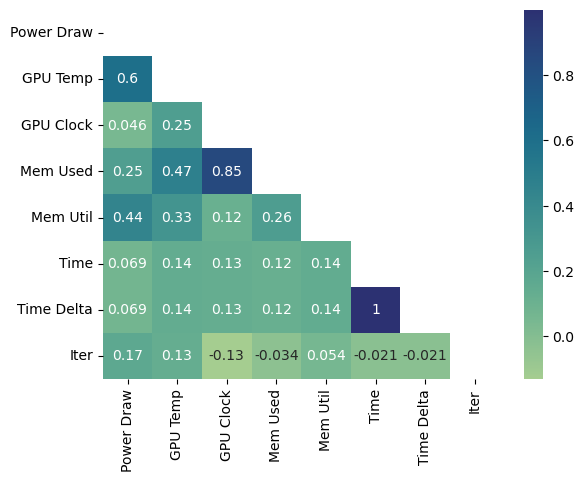

In [69]:
heatmap = sns.heatmap(tri_up, cmap='crest', annot=True)

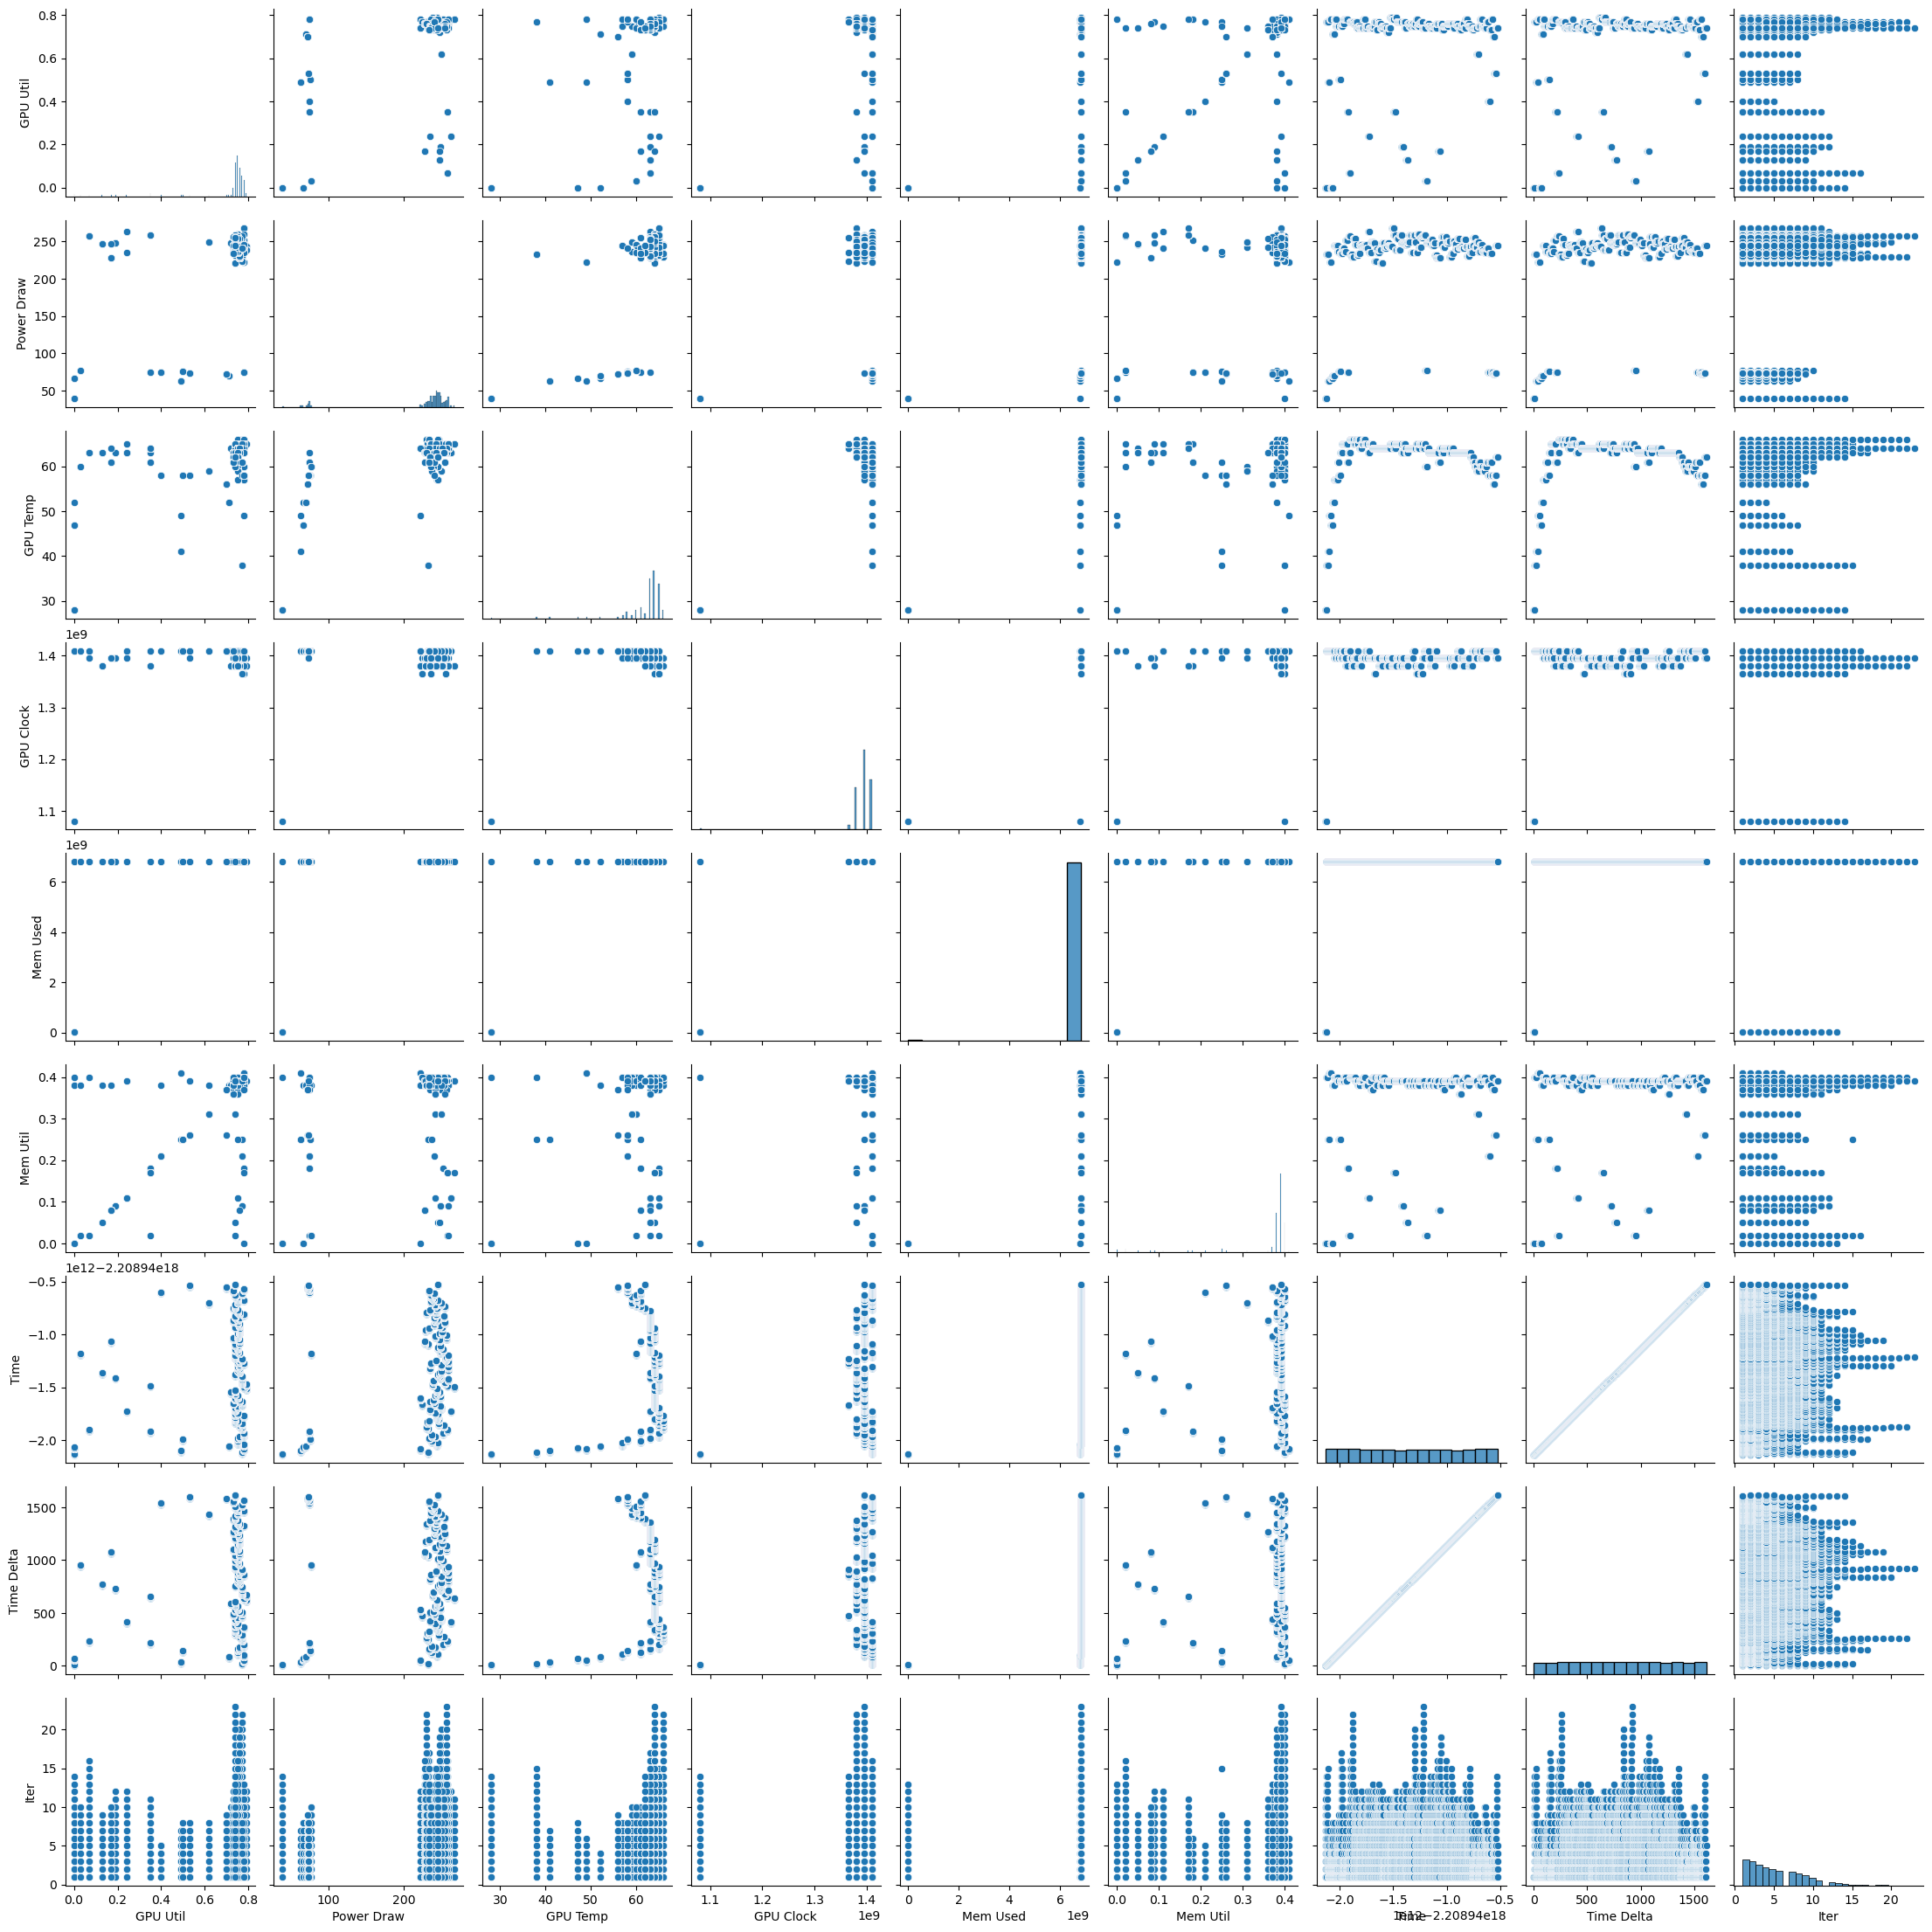

In [70]:
pair_plot = sns.pairplot(live_data, corner=False)

In [11]:
column_names = live.columns.tolist()
live_avg = dict(zip(column_names, [list(range(408))] * len(column_names)))
live_avg = pd.DataFrame(live_avg, dtype=np.float64)

In [12]:
temp_df = dict()
count = 0
for iter in range(1, len(reset_iters)):
    # print(f"Count: {str(count)}")
    start_index = reset_iters[iter-1]
    end_index = reset_iters[iter]-1
    # print(f"Current Slice: {str(start_index)}:{str(end_index)}")
    for col in range(len(column_names)):
        temp_list = live.iloc[start_index:end_index,  col].tolist()
        # print(f"On column: {str(col)} with the average: {str(np.average(temp_list))}")
        live_avg.iloc[count, col] = np.float64(np.average(temp_list))
    count+=1

In [13]:
live_avg = live_avg.iloc[:-1,:]

In [15]:
from sklearn.preprocessing import normalize, StandardScaler

live_avg_norm = normalize(live_avg)
ss = StandardScaler()
live_avg_scaled = ss.fit_transform(live_avg)

In [16]:
live_avg_scaled = pd.DataFrame(data=live_avg_scaled)
live_avg_scaled.columns = live_avg.columns


live_avg_norm = pd.DataFrame(data=live_avg_norm)
# live_avg_norm['Response Time'] = live_avg.iloc[: , -2:-1]
live_avg_norm.columns = live_avg_norm.columns

In [17]:
live_avg['Resonse Time'] = response_time
live_avg['Eval Rate'] = eval_rates[:-1]

In [18]:
live_avg.to_csv("../data/samples/mega_processed/live_avg.csv")
live_avg_scaled.to_csv("../data/samples/mega_processed/live_avg_scaled.csv")
live_avg_norm.to_csv("../data/samples/mega_processed/live_avg_norm.csv")